# Mathematical Engineering - Financial Engineering, FY 2024-2025
# Risk Management - Exercise 2: Corporate Bond Portfolio and Credit Single Factor Model

In [1]:
# Importing the libraries

import numpy as np
import pandas as pd

from scipy.optimize import fsolve   
from scipy.stats import norm

import pickle # Useful for the bootstrap

from utilities.ex0_utilities import bootstrap, get_discount_factor_by_zero_rates_linear_interp
from utilities.date_functions import business_date_offset, year_frac_act_x
from utilities.ex2_utilities import (
    defaultable_bond_dirty_price_from_intensity,
    defaultable_bond_dirty_price_from_z_spread,
)

## BOOTSTRAP PART: 
Here we import the data of the depos, futures and swaps and we also plot the curve in order to be sure that the imported data are the correct ones. Basically it is a copy and paste from Assigment 0

In [2]:
# IMPORT MKT DATA FOR BOOTSTRAP:
dt = pd.read_csv('mkt_data/dt.csv',
                index_col = 'Market',
                usecols = ['Market','TARGET'],
                converters = {'TARGET':pd.to_datetime})
settlement_date  = dt.TARGET['Settlement']
depo_converter = lambda x: float(x)/100.0  # apply the correct one

df_depos = pd.read_csv('mkt_data/depos.csv', 
                   index_col ='Depos',
                   usecols = ['Depos','ASK','BID'], 
                   converters={'Depos':pd.to_datetime,'BID':depo_converter,'ASK':depo_converter})
future_converter = lambda x: float(x) # apply the correct one

futures = pd.read_csv('mkt_data/futures.csv',
                      index_col ='Futures',
                      usecols = ['Futures','ASK','BID'],
                      converters={'Futures':pd.to_datetime,'BID':future_converter,'ASK':future_converter})
expiry = pd.read_csv('mkt_data/expiry.csv',
                     index_col = 'Futures',
                     usecols =['Futures', 'Settle', 'Expiry'], 
                     converters = {'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
df_futures = futures.join(expiry)
swap_converter = lambda x: float(x) # apply the correct one

df_swaps = pd.read_csv('mkt_data/swaps.csv',
                    index_col = 'Swaps',
                    usecols = ['Swaps','BID','ASK'],
                    converters={'Swaps':pd.to_datetime,'BID':swap_converter,'ASK':swap_converter})
rows = [0,1,-1]

In [3]:
# Storing the data in a dictionary
# Creo un dizionario per avere tutti i dati ordinati in un unico posto, stile libretto in 
# cui ci metto diversi fogli, ogni foglio ha un suo nome, così tutti i fogli li ho in un unico posto
# ordinati. I fogli sono i vari dati di mercato di swaps, deposit e futures il dizionario è 
# market_data
market_data = dict()
market_data["reference_date"] = settlement_date
market_data["depo"] = df_depos
market_data["futures"] = df_futures
market_data["swaps"] = df_swaps
pickle.dump(market_data, open("market_data.p", "wb"))

# Bootstrap
discount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)

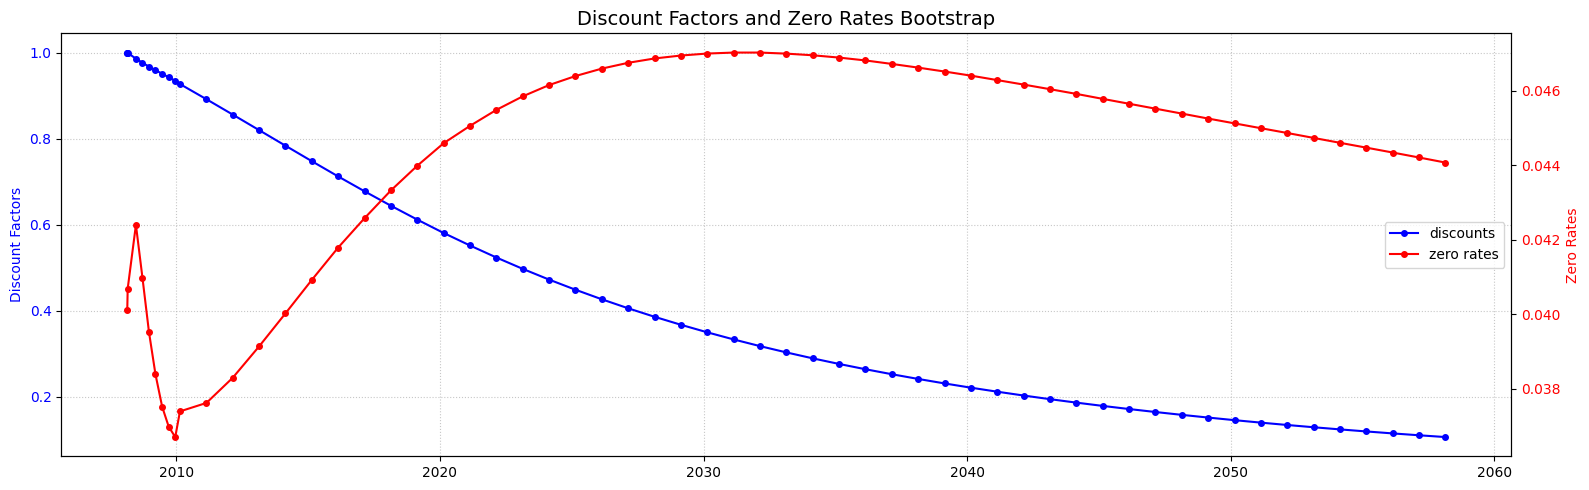

In [4]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(16, 5))
plt.title('Discount Factors and Zero Rates Bootstrap', fontsize=14)


ax1.plot(discount_factors.index, discount_factors.values, 'bo-', label='discounts', markersize=4)
ax1.set_ylabel('Discount Factors', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, linestyle=':', alpha=0.7)  


ax2 = ax1.twinx()

ax2.plot(zero_rates.index, zero_rates.values, 'ro-', label='zero rates', markersize=4)
ax2.set_ylabel('Zero Rates', color='r')
ax2.tick_params(axis='y', labelcolor='r')


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show()

#### Import market data

In [5]:
# =============================================================================
# Bootstrap the discount curve from market data (Assignment 0)
# =============================================================================

today = dt.TARGET['Today']
settlement_date  = dt.TARGET['Settlement']
discount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)

#### Portfolio A

In [6]:
# Parameters
maturity1 = 1  # Maturity in years
maturity2 = 2
notional1 = 1e7
notional2 = 1e7
coupon_rate1 = 0.055        # Error: we want the coupon rate in decimal mode, not percentage
coupon_rate2 = 0.07         # Error: we want the coupon rate in decimal mode, not percentage
coupon_freq1 = 2            # Coupon frequency in payments a years
coupon_freq2 = 2
dirty_price1 = 100.0
dirty_price2 = 103.0

recovery_rate = 0.40

rating = "IG"  # Credit rating

expiry1 = business_date_offset(settlement_date, year_offset=maturity1)          # Error: expiry was calculated from 'Today'
expiry2 = business_date_offset(settlement_date, year_offset=maturity2)          # Error: expiry was calculated from 'Today'

#### Z-spread

Price of defaultable bond, with coupon rate $c$ as function of the $z$-spread, ignoring the accrual:

$\hat{C}(t,T) = c\sum_{n=1}^N \delta_n\hat{B}(t,t_n)+\hat{B}(t,t_N)$

where 
- $\hat{B}(t,t_n) = B(t,t_n) \exp{ \{-\int_t^{t_n} z(s)ds\} }$

#### Q1: Z-spread calculation, assumed constant

In [7]:
z_spread_1y = fsolve(
    lambda z_spread: defaultable_bond_dirty_price_from_z_spread(
        settlement_date,            # Error: it was 'today'
        settlement_date,            # Error: it was 'today' 
        maturity1,
        coupon_rate1,
        coupon_freq1,
        z_spread[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,    # initial value from which this function starts to calculate the z-spread
)[0]            # takes the only element of the array that this function returns and saves it in z_spread_1y

z_spread_2y = fsolve(
    lambda z_spread: defaultable_bond_dirty_price_from_z_spread(
        settlement_date,
        settlement_date,            
        maturity2,
        coupon_rate2,
        coupon_freq2,
        z_spread[0],
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02, 
)[0]

print(f"Z-spread over {maturity1}y: {z_spread_1y:.6%}")
print(f"Z-spread over {maturity2}y: {z_spread_2y:.6%}")

Z-spread over 1y: 1.482794%
Z-spread over 2y: 1.523169%


#### Intensity

Price of defaultable bond, with coupon rate $c$ and recovery rate $\pi$, ignoring the accrual:

$\bar{C}(t,T) = c\sum_{n=1}^N \delta_n\bar{B}(t,t_n)+\bar{B}(t,t_N) +\pi \sum_{n=1}^N e(t;t_{n-1},t_n)$

where 

- $\bar{B}(t,T) = B(t,T) P(t,T)$ is the price of a defaultable zero coupon bond
- $P(t,T)=\exp{\{-\int_t^T \lambda(s)ds\}}$ is the survival probability up to time $T$, with $\lambda(s)$ intensity
- $e(t;t_{n-1},t_n)=B(t,t_n)(P(t,t_{n-1})-P(t,t_n))$ where $P(t,t_{n-1})-P(t,t_n)$ is the default probability between $t_{n-1}$ and $t_n$

#### Q2: Derive the average intensities for the two bonds and default probabilities

In [8]:
# Intensities average
h_1y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,
)[0]

h_2y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]
  
print(f"Average intensity over {maturity1}y: {h_1y:.6%}")
print(f"Average intensity over {maturity2}y: {h_2y:.6%}")

Average intensity over 1y: 2.432829%
Average intensity over 2y: 2.469875%


In [9]:
# Survival probabilities
surv_prob_1y = np.exp(-1*h_1y) 
surv_prob_2y = np.exp(-2*h_2y) 

# Defaul probabilities
default_prob_1y = (1 - surv_prob_1y)
default_prob_2y = (1- surv_prob_2y)

print(f"{maturity1}y default probability: {default_prob_1y:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y:.6%}")

1y default probability: 2.403474%
2y default probability: 4.819728%


#### Q3: Default probability estimates under the hp. of piecewise constant intensity

In [10]:
# Intensities piecewise (yearly constant)

# h_1y is still the same since we are assuming that the lambda is yearly piecewise constant

h_1y2y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        pd.Series(data=[h_1y, intensity[0]], index=[expiry1, expiry2]), # We use lambda_1 until 1y, then we adjust the price
        discount_factors,                                              # of the bond wr to dirty_price2 in order to find lambda
        100,                                                           # for the interval 1y->2y
    )
    - dirty_price2,
    x0=0.02,
)[0] 

print(f"Piecewise constant intensity over {maturity1}y: {h_1y:.6%}")
print(f"Piecewise constant intensity over {maturity2}y: {h_1y2y:.6%}")

Piecewise constant intensity over 1y: 2.432829%
Piecewise constant intensity over 2y: 2.510417%


Text(0.5, 1.0, 'Intensity')

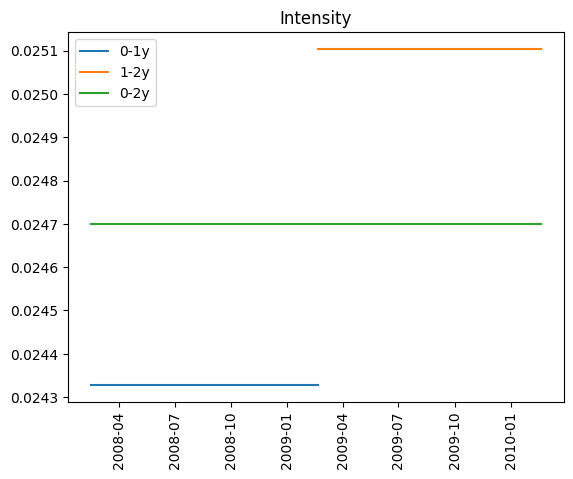

In [11]:
import matplotlib.pyplot as plt

plt.plot([today, expiry1], [h_1y, h_1y])
plt.plot([expiry1, expiry2], [h_1y2y, h_1y2y])
plt.plot([today, expiry2], [h_2y, h_2y])
plt.xticks(rotation=90)
plt.legend([f"0-{maturity1}y", f"{maturity1}-{maturity2}y", f"0-{maturity2}y"])
plt.title("Intensity")

In [12]:
# Survival probabilities
# surv_prob_1y remains the same of the previous point
surv_prob_2y = surv_prob_1y * np.exp(-h_1y2y * 1)

# Defaul probabilities
# default_prob_1y remains the same of the previous point
default_prob_2y = (1 - surv_prob_2y)

print(f"{maturity1}y default probability: {default_prob_1y:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y:.6%}")

1y default probability: 2.403474%
2y default probability: 4.823056%


#### Q4: Estimate the default probabilities under a shock of the mid-term creditworthiness

In [13]:
dirty_price1_shock = dirty_price1
dirty_price2_shock = 97.0

# Choosing piecewise constant intensity because it's a better approximation
h_1y_shock = h_1y 
h_1y2y_shock = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        pd.Series(data=[h_1y_shock, intensity[0]], index=[expiry1, expiry2]), # We use lambda_1 until 1y, then we adjust the price
        discount_factors,                                              # of the bond wr to dirty_price2 in order to find lambda
        100,                                                           # for the interval 1y->2y
    )
    - dirty_price2_shock,
    x0=0.02,
)[0] 


# Survival probabilities
surv_prob_1y_shock = np.exp(-1*h_1y_shock)
surv_prob_2y_shock = surv_prob_1y_shock * np.exp(-h_1y2y_shock * 1)

# Defaul probabilities
default_prob_1y_shock = (1 - surv_prob_1y_shock) 
default_prob_2y_shock = (1 - surv_prob_2y_shock) 

print(f"{maturity1}y default probability: {default_prob_1y_shock:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y_shock:.6%}")

1y default probability: 2.403474%
2y default probability: 14.792330%


#### Q5: Real world default probability from the rating transition matrix

In [14]:
# Rating is defined at the start of this notebook
transition_matrix = pd.DataFrame(
    [[0.73, 0.25, 0.02], [0.35, 0.6, 0.05], [0, 0, 1]],
    index=["IG", "HY", "Def"],
    columns=["IG", "HY", "Def"],
)

transition_matrix_2y = transition_matrix @ transition_matrix # Error: there was a * we don't want multiplication element*element 
                                                             # but we want to get a matrix by multiplying the rows with the columns

# Historical probabilities (matrices), the code goes in the line IG and the column default (ie, prob of passing IG->Default)
# in 1y and 2y respectively:
real_world_pd_1y = transition_matrix.loc[rating, "Def"]
real_world_pd_2y = transition_matrix_2y.loc[rating, "Def"]

print(f"One year real world default probability: {real_world_pd_1y:.2%}")
print(f"Two year real world default probability: {real_world_pd_2y:.2%}")

# The conditional probability (default in 2y given the fact that we survived the first one) is calculated via Bayes formula:
conditional_real_pd_1y_to_2y = (real_world_pd_2y - real_world_pd_1y) / (1 - real_world_pd_1y)

print(f"Real world conditional default probability (1y->2y): {conditional_real_pd_1y_to_2y:.4%}")

# Comparing with Q4 (the shock is applied only at 2y as written in request 5: "price of the one-year bond unchanged"):
conditional_implied_pd_1y_to_2y = (default_prob_2y_shock - default_prob_1y) / (1 - default_prob_1y)

print(f"Implied conditional default probability (Scenario 1): {conditional_implied_pd_1y_to_2y:.4%}")

One year real world default probability: 2.00%
Two year real world default probability: 4.71%
Real world conditional default probability (1y->2y): 2.7653%
Implied conditional default probability (Scenario 1): 12.6940%


#### Q6: Bond portfolio priced with transition matrix
One year IG zero-coupon bond

$\bar{B}^{IG}(t,t_1)=(1-\pi_{1,3})B(t,t_1) + \pi_{1,3} B(t,t_1/2)\eta$

Two years IG zero-coupon bond

$\bar{B}^{IG}(t,t_2)=\pi_{1,1}B(t,t_1)\bar{B}^{IG}(t_1,t_2) + \pi_{1,2}B(t,t_1)\bar{B}^{HY}(t_1,t_2)+\pi_{1,3}B(t,t_1/2) \eta$

where:
- $\eta$ is the recovery
- $\bar{B}^{IG}(t_1,t_2)$ is the forward zero coupon bond IG
- $\bar{B}^{HY}(t_1,t_2)$ is the forward zero coupon bond HY

In [15]:
# Parameters
issuers_num = 100  # Number of bonds in the portfolio
maturity = 2  # Maturity in years

rating = "IG"  # Credit rating

expiry = business_date_offset(today, year_offset=maturity)

# Same matrix as before
transition_matrix = pd.DataFrame(
    [[0.73, 0.25, 0.02], [0.35, 0.6, 0.05], [0, 0, 1]],     
    index=["IG", "HY", "Def"],
    columns=["IG", "HY", "Def"],
)

recovery_rate = 0.4
face_value = 1_000_000   # of each bond
rho = [0.0, 0.25, 0.50]
mc_simulations = 1_000_000

In [16]:
# a) Portfolio MtM assuming all issuers IG
# Get all the relevant discount factors for the following pricing formulas of zcb using the rating transition matrix

# IMPORTANT REMARK: we did not follow the structure of the box given to us by the laboratory Professors since we started working on it 
#                   from scratch in order to comprehend better what was going on in the pricing algorithm of this particular type of 
#                   zcb. Although we didn't follow the original structure, we tried to explain, using coincise but clear comments and 
#                   variable names, what is going on in this part of the code

# 0y -> 0.5y
expiry_halfyear = business_date_offset(settlement_date, year_offset=0, month_offset=6)
B_halfyear = get_discount_factor_by_zero_rates_linear_interp(settlement_date, expiry_halfyear, discount_factors.index, discount_factors)

# 0y -> 1y
B_1y = get_discount_factor_by_zero_rates_linear_interp(settlement_date, expiry1, discount_factors.index, discount_factors)

# 0y -> 1.5y
expiry_1year_and_half = business_date_offset(settlement_date, year_offset=1, month_offset=6)
B_1y_and_half = get_discount_factor_by_zero_rates_linear_interp(settlement_date, expiry_1year_and_half, discount_factors.index, discount_factors)

# 0y -> 2y
B_2y = get_discount_factor_by_zero_rates_linear_interp(settlement_date, expiry2, discount_factors.index, discount_factors)

#FORWARDS:
# 1y -> 1.5y
B_from_1y_to_1y_and_half = B_1y_and_half / B_1y

# 1y -> 2y
B_from_1y_to_2y = B_2y / B_1y

# Price of one year IG zero coupon bond 0y->1y
price_bond_IG_from_0y_to_1y = (1 - transition_matrix.loc["IG","Def"]) * B_1y + transition_matrix.loc["IG","Def"] * recovery_rate * B_halfyear

# Price of one year IG zero coupon bond 1y->2y
price_bond_IG_from_1y_to_2y = (1 - transition_matrix.loc["IG","Def"]) * B_from_1y_to_2y + transition_matrix.loc["IG","Def"] * recovery_rate * B_from_1y_to_1y_and_half

# Price of one year HY zero coupon bond 1y->2y
price_bond_HY_from_1y_to_2y = (1 - transition_matrix.loc["HY","Def"]) * B_from_1y_to_2y + transition_matrix.loc["HY","Def"] * recovery_rate * B_from_1y_to_1y_and_half

# Price of one year IG zero coupon bond 0y->2y
price_bond_IG_from_0y_to_2y = transition_matrix.loc["IG","IG"] * B_1y * price_bond_IG_from_1y_to_2y + transition_matrix.loc["IG","HY"] * B_1y * price_bond_HY_from_1y_to_2y + transition_matrix.loc["IG","Def"] * recovery_rate * B_halfyear

# The hypothesis is that all the issuers start from an IG rating and the face value for each zero coupon is 1 Mln €, so we can write the 
# price of the ptf as follows:
portfolio_MtM = issuers_num * face_value * price_bond_IG_from_0y_to_2y

print(f"6a. Total Portfolio MtM: € {portfolio_MtM:,.2f}")

6a. Total Portfolio MtM: € 90,131,690.79


In [17]:
# b) Evaluate the present value in 1 year time under various scenarios

# Forward price in case of Investment grade
# price_bond_IG_from_1y_to_2y already calculated in the previous box

# Forward price in case of high yield
# price_bond_HY_from_1y_to_2y already calculated in the previous box

print(f"6b. 1y Forward Price if IG: {price_bond_IG_from_1y_to_2y:.4f} (1€ notional)")
print(f"6b. 1y Forward Price if HY: {price_bond_HY_from_1y_to_2y:.4f} (1€ notional)")

6b. 1y Forward Price if IG: 0.9527 (1€ notional)
6b. 1y Forward Price if HY: 0.9356 (1€ notional)


In [18]:
# c) Monte Carlo simulation
# Barriers and PnL for a single IG issuer

# we define what is the critical value K under which the company defaults: P(v_i < K_1) = pi_[1,3]
# IMPORTANT: since, as requested, the VaR is only on 1y and all the issuers start from IG, for default we have to consider only the
#            case in which we go from IG to default in 1y, ie only the element in the first row and third column of the matrix.
#            A similar thinking has to be done for the downgrade and upgrade barriers

barrier_default = norm.ppf(transition_matrix.loc["IG","Def"]) 
barrier_downgrade = norm.ppf(transition_matrix.loc["IG","Def"] + transition_matrix.loc["IG","HY"]) 
barrier_upgrade = np.inf  # IG name can't be upgraded

# Present value of the price in the two cases: 
# 1. We are still in IG after 1y
PV_if_IG_after_1y = B_1y * price_bond_IG_from_1y_to_2y
# 2. We had a downgrade to HY after 1y
PV_if_HY_after_1y = B_1y * price_bond_HY_from_1y_to_2y

# IMPORTANT: as fwd price we use price_bond_IG_from_0y_to_2y since it takes into account any possible future scenario (ie, the
#            possibility that after 1y you had a downgrade and also that after 1y you are still in IG. It includes also the 
#            possibility of default)
# In case of default we get only the recovery, which is given back at half year
loss_given_default = (recovery_rate * B_halfyear) - price_bond_IG_from_0y_to_2y
loss_given_downgrade = PV_if_HY_after_1y - price_bond_IG_from_0y_to_2y
loss_status_quo = PV_if_IG_after_1y - price_bond_IG_from_0y_to_2y
loss_upgrade = 0     # upgrade from IG is not possible

In [19]:
# 3 correlation scenarios
# to have the same result at each run, fix the seed
np.random.seed(43)

y = np.random.normal(size=(mc_simulations, 1))                 # y is (1Mln,1)
eps = np.random.normal(size=(mc_simulations, issuers_num))     # eps is (1Mln, number of issuers)

# Adding correlation
r = np.array(rho).reshape(len(rho), 1, 1)           # => r is (3,1,1)
v = np.sqrt(r) * y + np.sqrt(1 - r) * eps

In [20]:
# count of defaults, downgrades, upgrades in each simulation...
# the following lines of code are already quite explicative themselves

defaults = (v < barrier_default).sum(axis=2)
downgrades = ((v >= barrier_default) & (v < barrier_downgrade)).sum(axis=2)
status_quo = (v >= barrier_downgrade).sum(axis=2)
upgrades = np.zeros((len(rho), mc_simulations))

print(f"Average defaults: {defaults.mean()}")
print(f"Average downgrades: {downgrades.mean()}")


Average defaults: 1.9987386666666667
Average downgrades: 24.999183666666667


In [21]:
# Marginal distributions (check)
# We expect to have marginal probability practically identical changing the values of rho, since the correlation 
# doesn't play a role in the marginal probabilities:
prob_default = defaults.mean(axis=1) / issuers_num
prob_downgrade = downgrades.mean(axis=1) / issuers_num
prob_status_quo = status_quo.mean(axis=1) / issuers_num
prob_upgrades = upgrades.mean(axis=1) / issuers_num

for i, r_val in enumerate(rho):
    print(f"\n--- Marginal probabilities (rho = {r_val}) ---")
    print(f"Prob. Default:    {prob_default[i]:.4f}")
    print(f"Prob. Downgrade:  {prob_downgrade[i]:.4f}")
    print(f"Prob. Status Quo: {prob_status_quo[i]:.4f}")


--- Marginal probabilities (rho = 0.0) ---
Prob. Default:    0.0200
Prob. Downgrade:  0.2500
Prob. Status Quo: 0.7300

--- Marginal probabilities (rho = 0.25) ---
Prob. Default:    0.0200
Prob. Downgrade:  0.2500
Prob. Status Quo: 0.7300

--- Marginal probabilities (rho = 0.5) ---
Prob. Default:    0.0200
Prob. Downgrade:  0.2500
Prob. Status Quo: 0.7300


In [22]:
# Evaluating the one-year 99% VaR by taking into account defaults only/defaults and rating changes:

# The following lines of code compute the VaR and EL with different values of rho and also considering only the defaults or also the downgrades

# REMARK ON THE CODE => we change the value of the variable 'scenario' at every iteration of the for, this is possible ONLY because the 
#                       valuation of the VaR and the EL is also done and printed out in the for cycle

for defaults_only in [True, False]:
    print(f"=== MIGRATION RISK: {'IGNORED (Defaults Only)' if defaults_only else 'INCLUDED (Defaults + Downgrades)'} ===")
    
    if defaults_only:
        # I treat, in case of only defaults, the downgrades as they stayed in the same position.
        # This is an approximation, we thought it was better to do as we did than considering only the status quo
        # and totally forget about the losses given by the downgrades (you are making disappearing people basically), 
        # so we treated the downgrades as they stayed in the same position.
        scenario = defaults * loss_given_default + (status_quo + downgrades) * loss_status_quo
        scenario_only_default = scenario.copy()
    else:
        scenario = defaults * loss_given_default + downgrades * loss_given_downgrade + status_quo * loss_status_quo
        # We don't write the upgrades since they are zero
        scenario_default_and_downgrade = scenario.copy()

    VaR = -np.quantile(scenario, 0.01, axis=1) * face_value
    expected_loss = -scenario.mean(axis=1) * face_value

    for i, r_val in enumerate(rho):
        print(f"[rho = {r_val:4.2f}] Expected loss: € {expected_loss[i]:>10,.2f} | VaR 99%: € {VaR[i]:>12,.2f}")
    
    print("-" * 70)

=== MIGRATION RISK: IGNORED (Defaults Only) ===
[rho = 0.00] Expected loss: € -412,357.60 | VaR 99%: € 1,685,209.44
[rho = 0.25] Expected loss: € -412,035.21 | VaR 99%: € 6,927,315.88
[rho = 0.50] Expected loss: € -412,490.22 | VaR 99%: € 13,742,054.26
----------------------------------------------------------------------
=== MIGRATION RISK: INCLUDED (Defaults + Downgrades) ===
[rho = 0.00] Expected loss: €    -689.93 | VaR 99%: € 2,080,377.25
[rho = 0.25] Expected loss: €    -462.91 | VaR 99%: € 7,898,770.09
[rho = 0.50] Expected loss: €    -871.10 | VaR 99%: € 14,762,904.45
----------------------------------------------------------------------


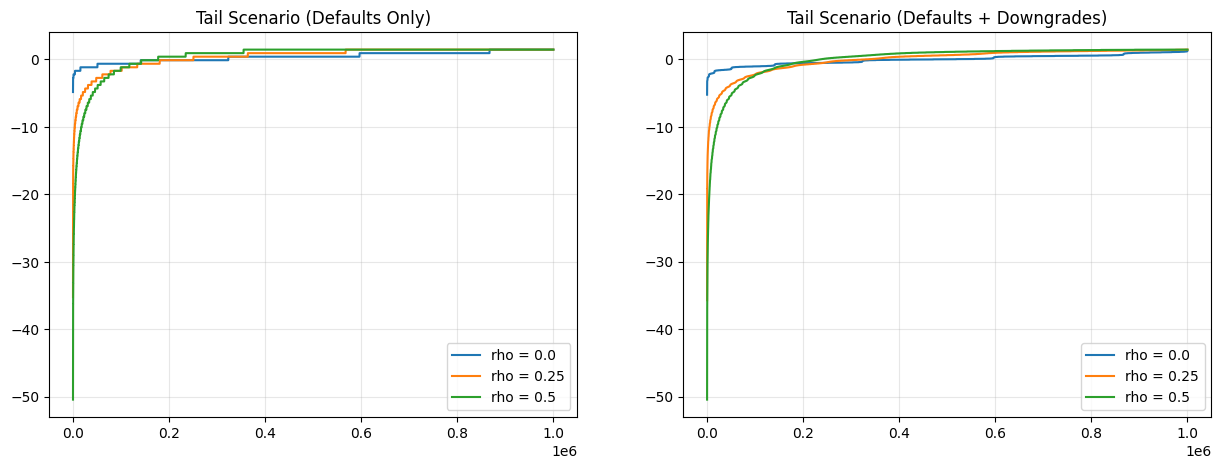

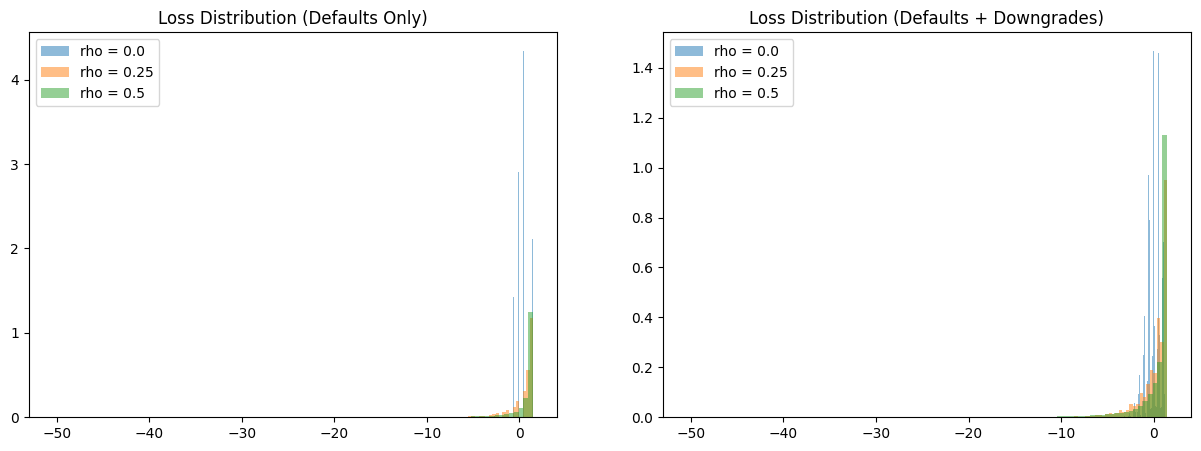

In [23]:
# Plot
import matplotlib.pyplot as plt

# sort the scenarios
scenario_only_default.sort(axis=1)
scenario_default_and_downgrade.sort(axis=1)

# Plot 1: TAILS
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) # Crea una figura con 2 grafici (1 riga, 2 colonne)

axes[0].plot(scenario_only_default.T)
axes[0].set_title("Tail Scenario (Defaults Only)")
axes[0].legend([f"rho = {r}" for r in rho])
axes[0].grid(True, alpha=0.3)

axes[1].plot(scenario_default_and_downgrade.T)
axes[1].set_title("Tail Scenario (Defaults + Downgrades)")
axes[1].legend([f"rho = {r}" for r in rho])
axes[1].grid(True, alpha=0.3)

plt.show()

# Plot 2: LOSS DISTRIBUTIONS
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i in range(len(rho)):
    axes[0].hist(scenario_only_default[i], bins=100, density=True, alpha=0.5, label=f"rho = {rho[i]}")
    axes[1].hist(scenario_default_and_downgrade[i], bins=100, density=True, alpha=0.5, label=f"rho = {rho[i]}")

axes[0].set_title("Loss Distribution (Defaults Only)")
axes[0].legend()

axes[1].set_title("Loss Distribution (Defaults + Downgrades)")
axes[1].legend()

plt.show()